In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16,6)

In [37]:
file_path = "./buoy/jennettespier.txt"

# read file ignoring header lines starting with #
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    comment="#"
)

df.head()

C:\Users\monaz\AppData\Local\Temp\ipykernel_18864\598796590.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,2025,01,01.1,00,26,999,99.0,99.0.1,1.32,5.56,4.89,134,9999.0,999.0,10.9,999.0.1,99.0.2,99.00
0,2025,1,1,0,56,999,99.0,99.0,1.40,6.25,5.20,121,9999.0,999.0,10.9,999.0,99.0,99.0
1,2025,1,1,1,26,999,99.0,99.0,1.32,5.88,4.96,120,9999.0,999.0,10.8,999.0,99.0,99.0
2,2025,1,1,1,56,999,99.0,99.0,1.30,5.88,4.83,131,9999.0,999.0,10.8,999.0,99.0,99.0
3,2025,1,1,2,26,999,99.0,99.0,1.22,6.25,4.83,117,9999.0,999.0,11.0,999.0,99.0,99.0
4,2025,1,1,2,56,999,99.0,99.0,1.17,5.26,4.75,139,9999.0,999.0,11.1,999.0,99.0,99.0


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "./buoy/jennettespier.txt"

# Read the first header line manually
with open(file_path, "r") as f:
    first_header = f.readline().strip()

# Build column names from the first header line
columns = first_header.lstrip("#").split()

# Read the actual data, skipping both header lines
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    skiprows=2,
    names=columns
)

print(df.head())
print(df.columns)
df["datetime"] = pd.to_datetime(
    dict(
        year=df["YY"],
        month=df["MM"],
        day=df["DD"],
        hour=df["hh"],
        minute=df["mm"]
    )
)

df = df.sort_values("datetime").reset_index(drop=True)

     YY  MM  DD  hh  mm  WDIR  WSPD   GST  WVHT   DPD   APD  MWD    PRES  \
0  2025   1   1   0  26   999  99.0  99.0  1.32  5.56  4.89  134  9999.0   
1  2025   1   1   0  56   999  99.0  99.0  1.40  6.25  5.20  121  9999.0   
2  2025   1   1   1  26   999  99.0  99.0  1.32  5.88  4.96  120  9999.0   
3  2025   1   1   1  56   999  99.0  99.0  1.30  5.88  4.83  131  9999.0   
4  2025   1   1   2  26   999  99.0  99.0  1.22  6.25  4.83  117  9999.0   

    ATMP  WTMP   DEWP   VIS  TIDE  
0  999.0  10.9  999.0  99.0  99.0  
1  999.0  10.9  999.0  99.0  99.0  
2  999.0  10.8  999.0  99.0  99.0  
3  999.0  10.8  999.0  99.0  99.0  
4  999.0  11.0  999.0  99.0  99.0  
Index(['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD',
       'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'],
      dtype='object')


C:\Users\monaz\AppData\Local\Temp\ipykernel_18864\2521363079.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [39]:
missing_vals = [99, 99.0, 999, 999.0, 9999, 9999.0]

df["WVHT"] = df["WVHT"].replace(missing_vals, np.nan)
df["DPD"] = df["DPD"].replace(missing_vals, np.nan)

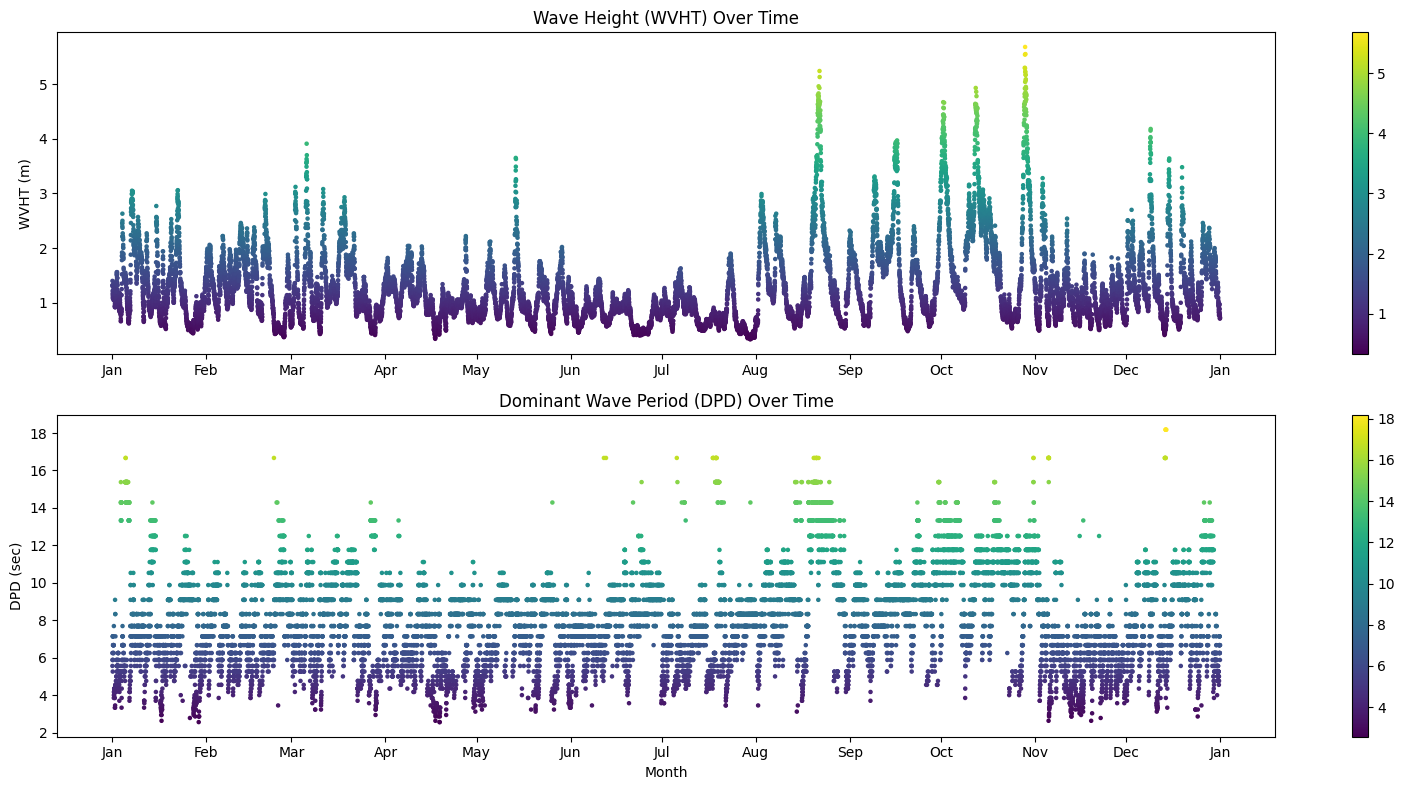

In [40]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(2,1, figsize=(16,8))

# WVHT
sc1 = ax[0].scatter(df["datetime"], df["WVHT"], c=df["WVHT"], s=5)
ax[0].set_title("Wave Height (WVHT) Over Time")
ax[0].set_ylabel("WVHT (m)")
fig.colorbar(sc1, ax=ax[0])

# DPD
sc2 = ax[1].scatter(df["datetime"], df["DPD"], c=df["DPD"], s=5)
ax[1].set_title("Dominant Wave Period (DPD) Over Time")
ax[1].set_ylabel("DPD (sec)")
fig.colorbar(sc2, ax=ax[1])

# Format x-axis to show months
for a in ax:
    a.xaxis.set_major_locator(mdates.MonthLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

In [41]:
import pandas as pd
import numpy as np

# -------------------------
# assuming df is already loaded and datetime already created
# -------------------------

# Clean missing values
missing_vals = [99, 99.0, 99.00, 999, 999.0, 9999, 9999.0]
for col in ["WVHT", "DPD", "MWD"]:
    df[col] = df[col].replace(missing_vals, np.nan)

# keep only what you care about
table_df = df[["datetime", "WVHT", "DPD", "MWD"]].copy()

# optional: round values for display
table_df["WVHT"] = table_df["WVHT"].round(2)
table_df["DPD"] = table_df["DPD"].round(2)
table_df["MWD"] = table_df["MWD"].round(0)

# If full year is too huge, preview first 200 rows
preview_df = table_df.head(200)

styled = (
    preview_df.style
    .format({
        "datetime": lambda x: x.strftime("%Y-%m-%d %H:%M"),
        "WVHT": "{:.2f}",
        "DPD": "{:.2f}",
        "MWD": "{:.0f}"
    })
    .background_gradient(subset=["WVHT"], cmap="YlGnBu")
    .background_gradient(subset=["DPD"], cmap="YlOrRd")
    .background_gradient(subset=["MWD"], cmap="PuRd")
)

In [42]:
styled

,datetime,WVHT,DPD,MWD
0,2025-01-01 00:26,1.32,5.56,134
1,2025-01-01 00:56,1.40,6.25,121
2,2025-01-01 01:26,1.32,5.88,120
3,2025-01-01 01:56,1.30,5.88,131
4,2025-01-01 02:26,1.22,6.25,117
5,2025-01-01 02:56,1.17,5.26,139
6,2025-01-01 03:26,1.13,7.14,124
7,2025-01-01 03:56,1.08,7.14,107
8,2025-01-01 04:26,1.10,7.14,121
9,2025-01-01 04:56,1.15,6.67,130


In [43]:
heat_df = df[["datetime","WVHT","DPD"]].copy()

heat_df["date"] = heat_df["datetime"].dt.date
heat_df["time"] = heat_df["datetime"].dt.strftime("%H:%M")

wvht_grid = heat_df.pivot_table(
    index="date",
    columns="time",
    values="WVHT",
    aggfunc="mean"
)

dpd_grid = heat_df.pivot_table(
    index="date",
    columns="time",
    values="DPD",
    aggfunc="mean"
)

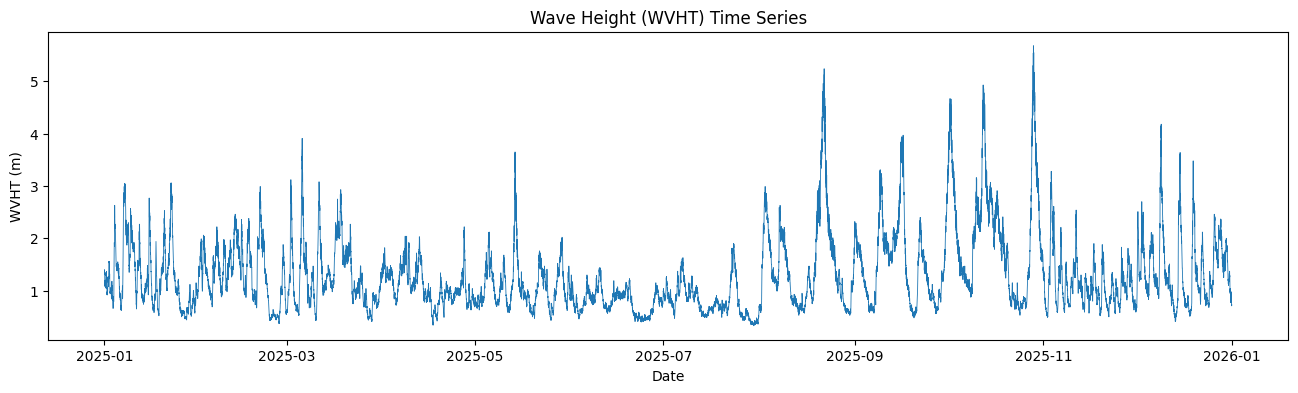

In [44]:
plt.figure(figsize=(16,4))

plt.plot(df["datetime"], df["WVHT"], linewidth=0.6)

plt.title("Wave Height (WVHT) Time Series")
plt.ylabel("WVHT (m)")
plt.xlabel("Date")

plt.show()

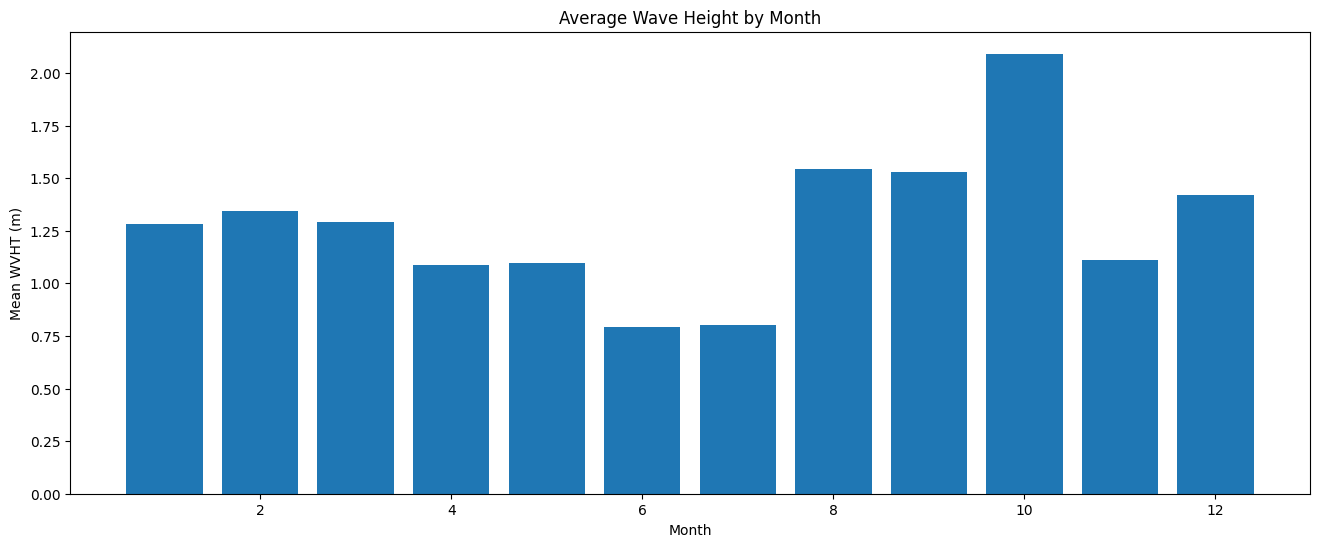

In [45]:
df["month"] = df["datetime"].dt.month

monthly = df.groupby("month")["WVHT"].mean()

plt.bar(monthly.index, monthly.values)

plt.xlabel("Month")
plt.ylabel("Mean WVHT (m)")
plt.title("Average Wave Height by Month")

plt.show()

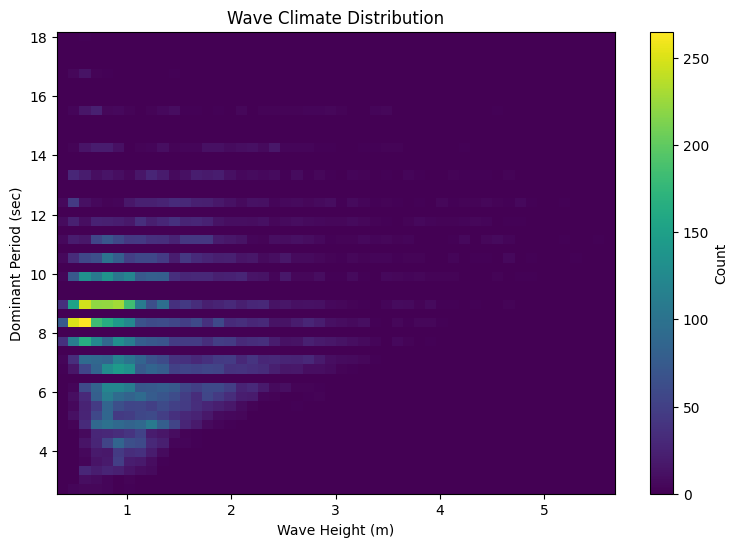

In [46]:
plt.figure(figsize=(9,6))

plt.hist2d(df["WVHT"], df["DPD"], bins=50)

plt.xlabel("Wave Height (m)")
plt.ylabel("Dominant Period (sec)")
plt.title("Wave Climate Distribution")

plt.colorbar(label="Count")

plt.show()